# Rob2Pheno RGB / Depth Alignment Check

Verifies whether the Rob2Pheno Depth maps align spatially with the RGB images. Adapted from `check_papple_alignment.ipynb`.

Three checks:
1. **Visual** — RGB / Depth / annotation-overlay side-by-side for random samples + the worst-by-valid-in-fruit samples.
2. **Edge agreement** — Canny edges on RGB vs Sobel-gradient edges on Depth; IoU and edge-recall in a dilated tolerance band.
3. **Dataset-wide** — distributions of `valid_frac_in_fruit` and depth dynamic range, computed inline (no precomputed report exists for Rob2Pheno).

Split: **train** (83 images, 2-class: redfruit / greenfruit).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from PIL import Image, ImageDraw
from scipy import ndimage as ndi

try:
    from skimage.feature import canny
    from skimage.filters import sobel
except ImportError as e:
    raise SystemExit("This notebook needs scikit-image: pip install scikit-image") from e

try:
    import tifffile  # robust TIFF reader; preferred for Rob2Pheno depth
except ImportError:
    tifffile = None

ROOT = Path.cwd()
DATASET = ROOT / "data" / "Rob2Pheno"
RGB_DIR = DATASET / "RGB"
DEPTH_DIR = DATASET / "Depth"
SPLIT = "train"

assert DATASET.exists(), f"Missing {DATASET} — run notebook from repo root"

with open(DATASET / f"{SPLIT}_2class.JSON") as f:
    coco = json.load(f)

imgs = {im["id"]: im for im in coco["images"]}
anns_by_img = {}
for a in coco["annotations"]:
    anns_by_img.setdefault(a["image_id"], []).append(a)

CAT_NAME = {c["id"]: c["name"] for c in coco["categories"]}
CAT_COLOR = {1: "red", 2: "lime"}

print(f"{SPLIT}: {len(imgs)} images, {len(coco['annotations'])} annotations, categories={CAT_NAME}")
print(f"tifffile available: {tifffile is not None}")

train: 83 images, 1074 annotations, categories={1: 'redfruit', 2: 'greenfruit'}
tifffile available: True


In [2]:
def stem_for(im):
    return Path(im["file_name"]).stem.replace("_RGB", "")

def _load_image(path):
    """Robust TIFF loader. PIL's lazy decode + np.asarray has been observed
    to segfault on the Rob2Pheno depth TIFFs, so prefer tifffile and fall
    back to a force-decoded PIL path."""
    p = str(path)
    if tifffile is not None:
        try:
            return np.asarray(tifffile.imread(p))
        except Exception:
            pass
    with Image.open(p) as im:
        im.load()  # force decode before np conversion
        return np.array(im)

def _to_depth_2d(arr):
    """Rob2Pheno depth TIFFs may be saved as RGB triplicates of the same
    value (PIL reports mode='RGB'). Collapse to a single 2-D array."""
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr

def load_pair(im):
    rgb = _load_image(RGB_DIR / im["file_name"])
    if rgb.ndim == 2:
        rgb = np.stack([rgb] * 3, axis=-1)
    elif rgb.shape[-1] == 4:
        rgb = rgb[..., :3]
    depth = _to_depth_2d(_load_image(DEPTH_DIR / f"{stem_for(im)}_DEPTH.tiff"))
    return rgb, depth

def _polys_from_ann(ann):
    seg = ann["segmentation"]
    # Rob2Pheno: flat [x1,y1,x2,y2,...] OR PApple-style [[x1,y1,...]]
    if seg and isinstance(seg[0], (int, float)):
        return [seg]
    return [s for s in seg if isinstance(s, list)]

def rasterize_fruit_mask(anns, h, w):
    img = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(img)
    polys_by_cat = {}
    for ann in anns:
        cat = ann["category_id"]
        for flat in _polys_from_ann(ann):
            pts = list(zip(flat[0::2], flat[1::2]))
            if len(pts) < 3:
                continue
            draw.polygon(pts, fill=1)
            polys_by_cat.setdefault(cat, []).append(np.array(pts))
    return np.asarray(img, dtype=bool), polys_by_cat

# Smoke-test the loader on one image so a crash here is obvious, not buried
# inside the plotting loop.
_test_im = next(iter(imgs.values()))
_rgb, _depth = load_pair(_test_im)
print(f"smoke-test  rgb={_rgb.shape} {_rgb.dtype}   depth={_depth.shape} {_depth.dtype}   "
      f"depth min/max={int(_depth.min())}/{int(_depth.max())}   zeros={float((_depth==0).mean()):.3f}")

smoke-test  rgb=(720, 1280, 3) uint8   depth=(720, 1280) uint8   depth min/max=0/255   zeros=0.269


## 1. Side-by-side visual check

RGB / Depth / RGB-with-fruit-polygons. Red polys = `redfruit`, green polys = `greenfruit`. If alignment is correct, high-gradient regions in the depth panel should sit under the outlined fruits in the third panel.

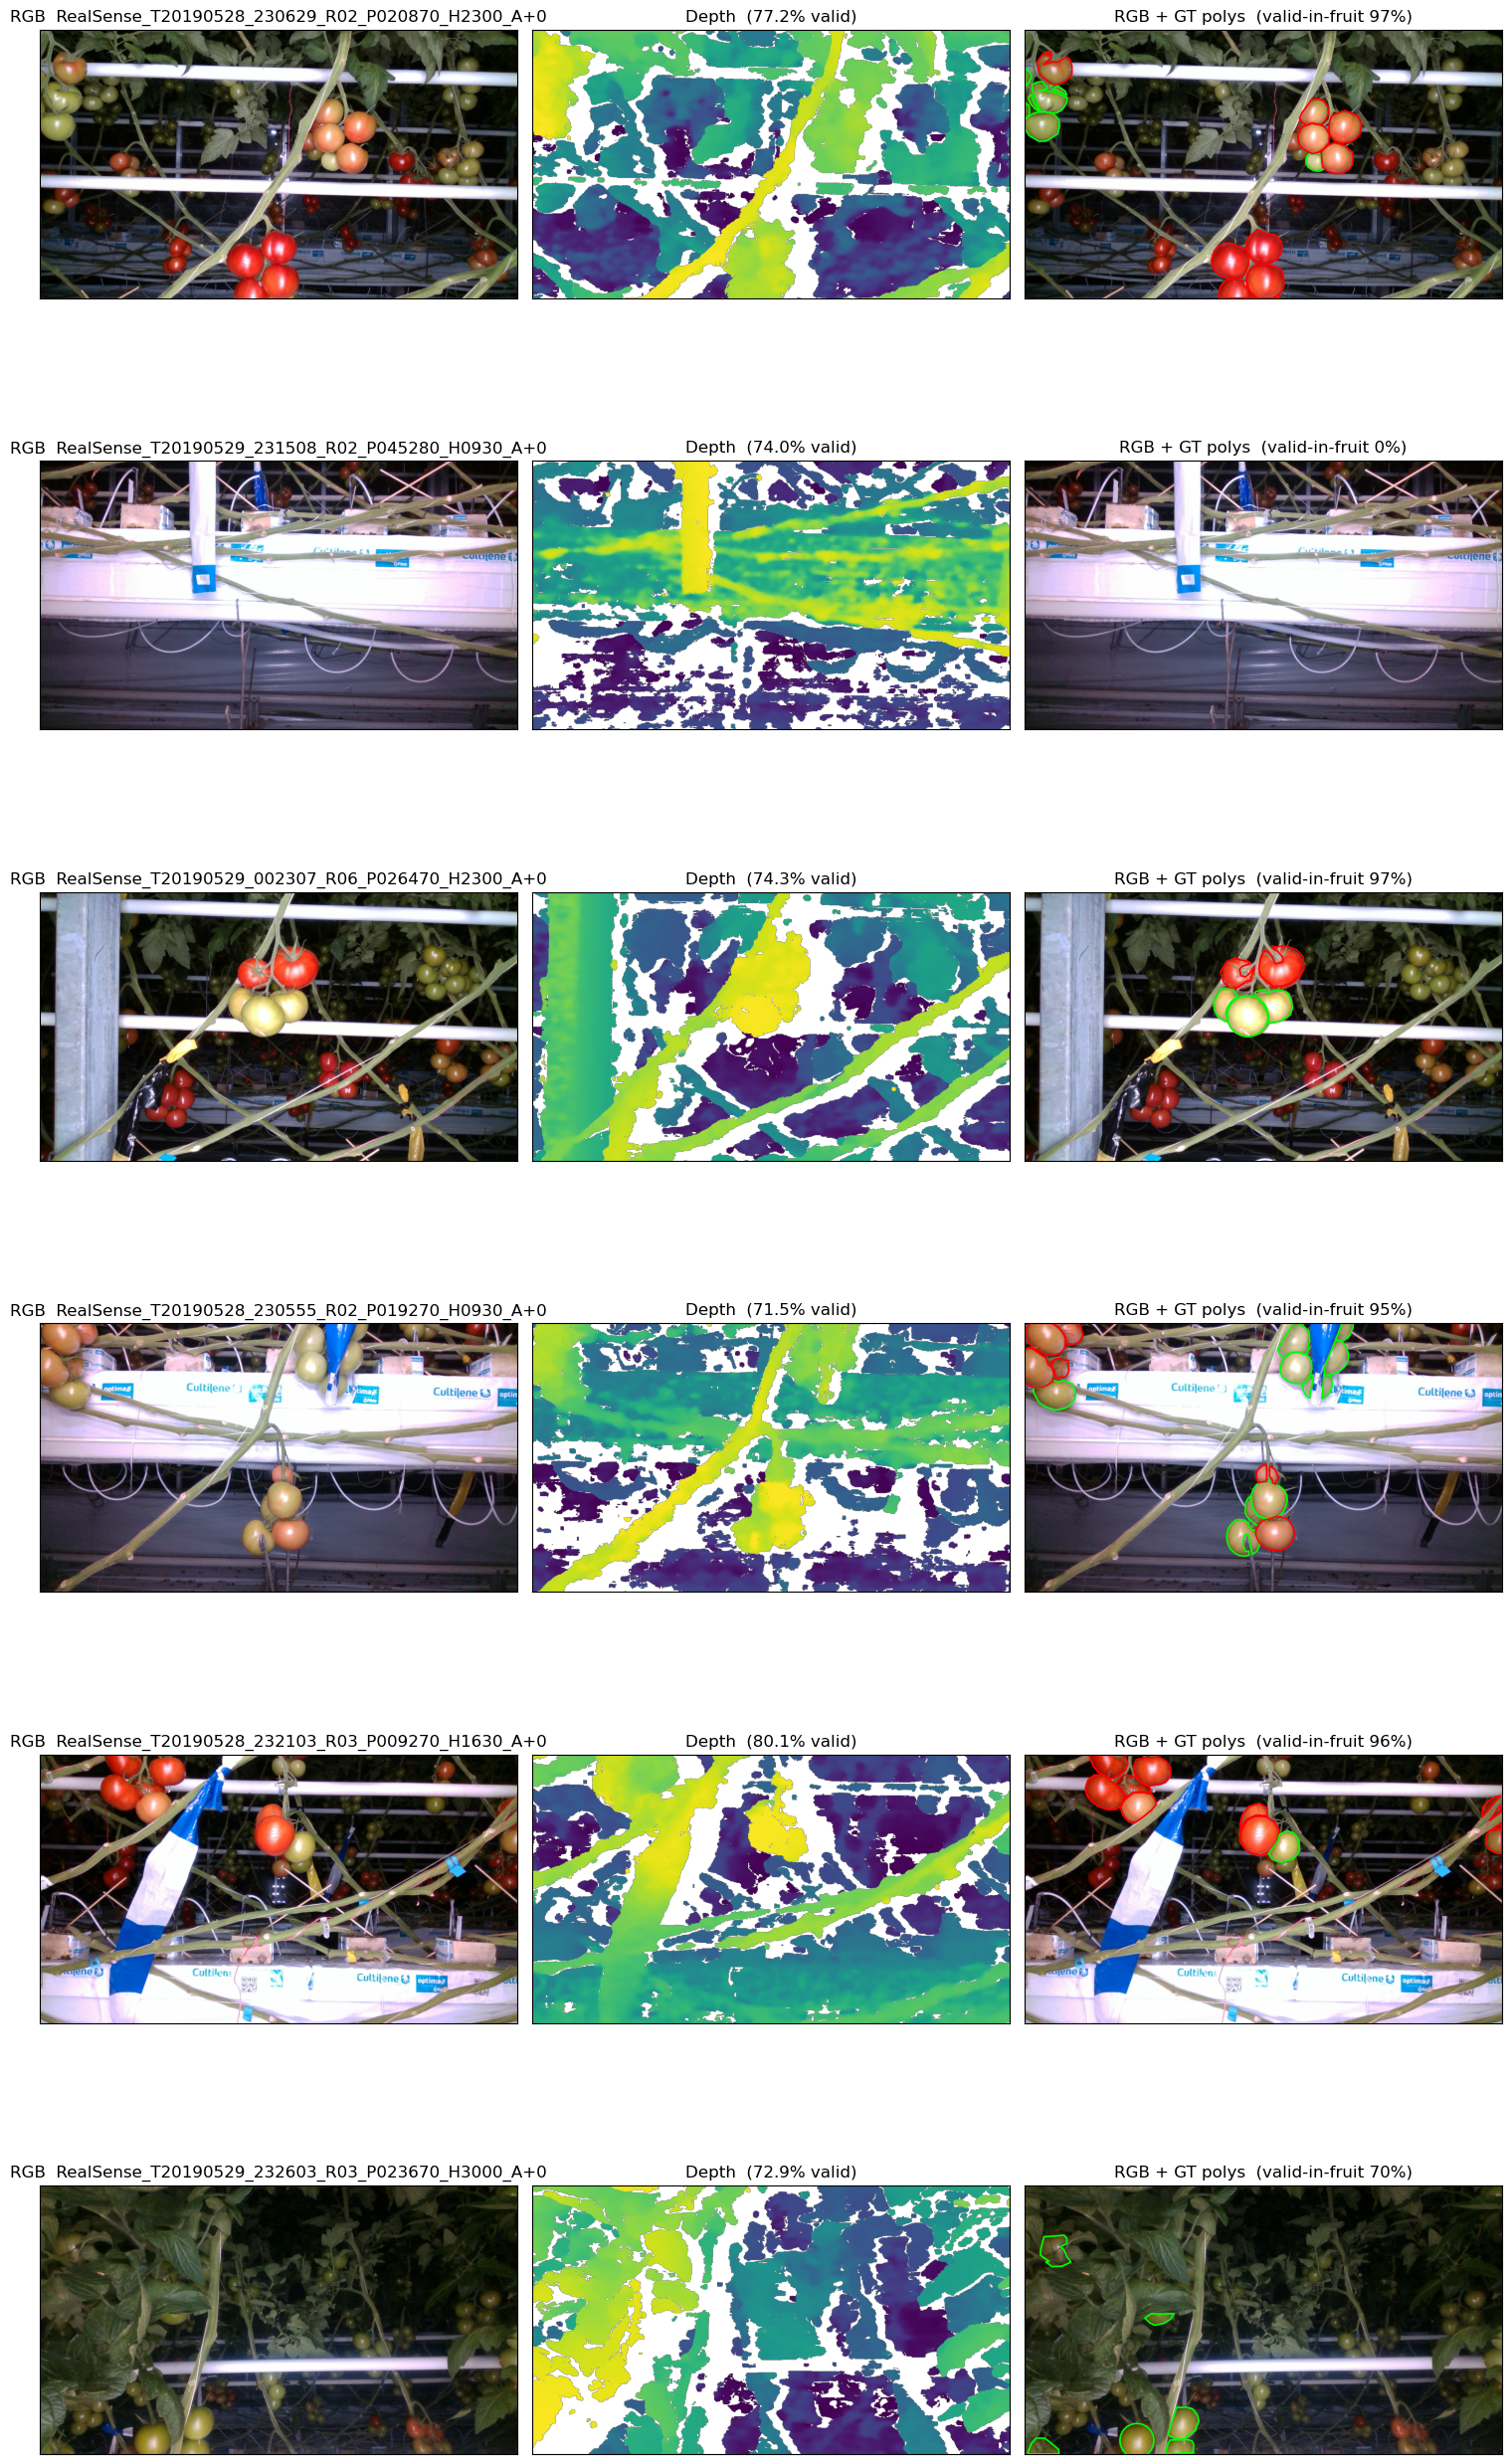

In [3]:
def show_pair(im, ax_row):
    rgb, depth = load_pair(im)
    h, w = depth.shape
    anns = anns_by_img.get(im["id"], [])
    fruit, polys_by_cat = rasterize_fruit_mask(anns, h, w)

    ax_row[0].imshow(rgb)
    ax_row[0].set_title(f"RGB  {stem_for(im)[:48]}")

    masked_depth = np.where(depth > 0, depth, np.nan)
    ax_row[1].imshow(masked_depth, cmap="viridis")
    ax_row[1].set_title(f"Depth  ({(depth>0).mean()*100:.1f}% valid)")

    ax_row[2].imshow(rgb)
    for cat, polys in polys_by_cat.items():
        patches = [MplPolygon(p, closed=True) for p in polys]
        pc = PatchCollection(patches, facecolor="none",
                             edgecolor=CAT_COLOR.get(cat, "yellow"), linewidth=1.2)
        ax_row[2].add_collection(pc)
    valid_in_fruit = (fruit & (depth > 0)).sum() / max(fruit.sum(), 1)
    ax_row[2].set_title(f"RGB + GT polys  (valid-in-fruit {valid_in_fruit*100:.0f}%)")

    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

rng = np.random.default_rng(0)
ids = list(imgs.keys())
sample_ids = rng.choice(ids, size=6, replace=False)

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(15, 4.5 * len(sample_ids)))
for r, sid in enumerate(sample_ids):
    show_pair(imgs[sid], axes[r])
plt.tight_layout(); plt.show()

## 2. Edge-agreement metric

Canny edges on RGB vs Sobel-gradient edges on Depth, with a 3-px dilated tolerance band. Same definitions as the PApple notebook:

- **`edge_recall`** — fraction of RGB edge pixels that fall within the dilated depth-edge band.
- **`edge_iou`** — IoU between dilated RGB and dilated depth edges.

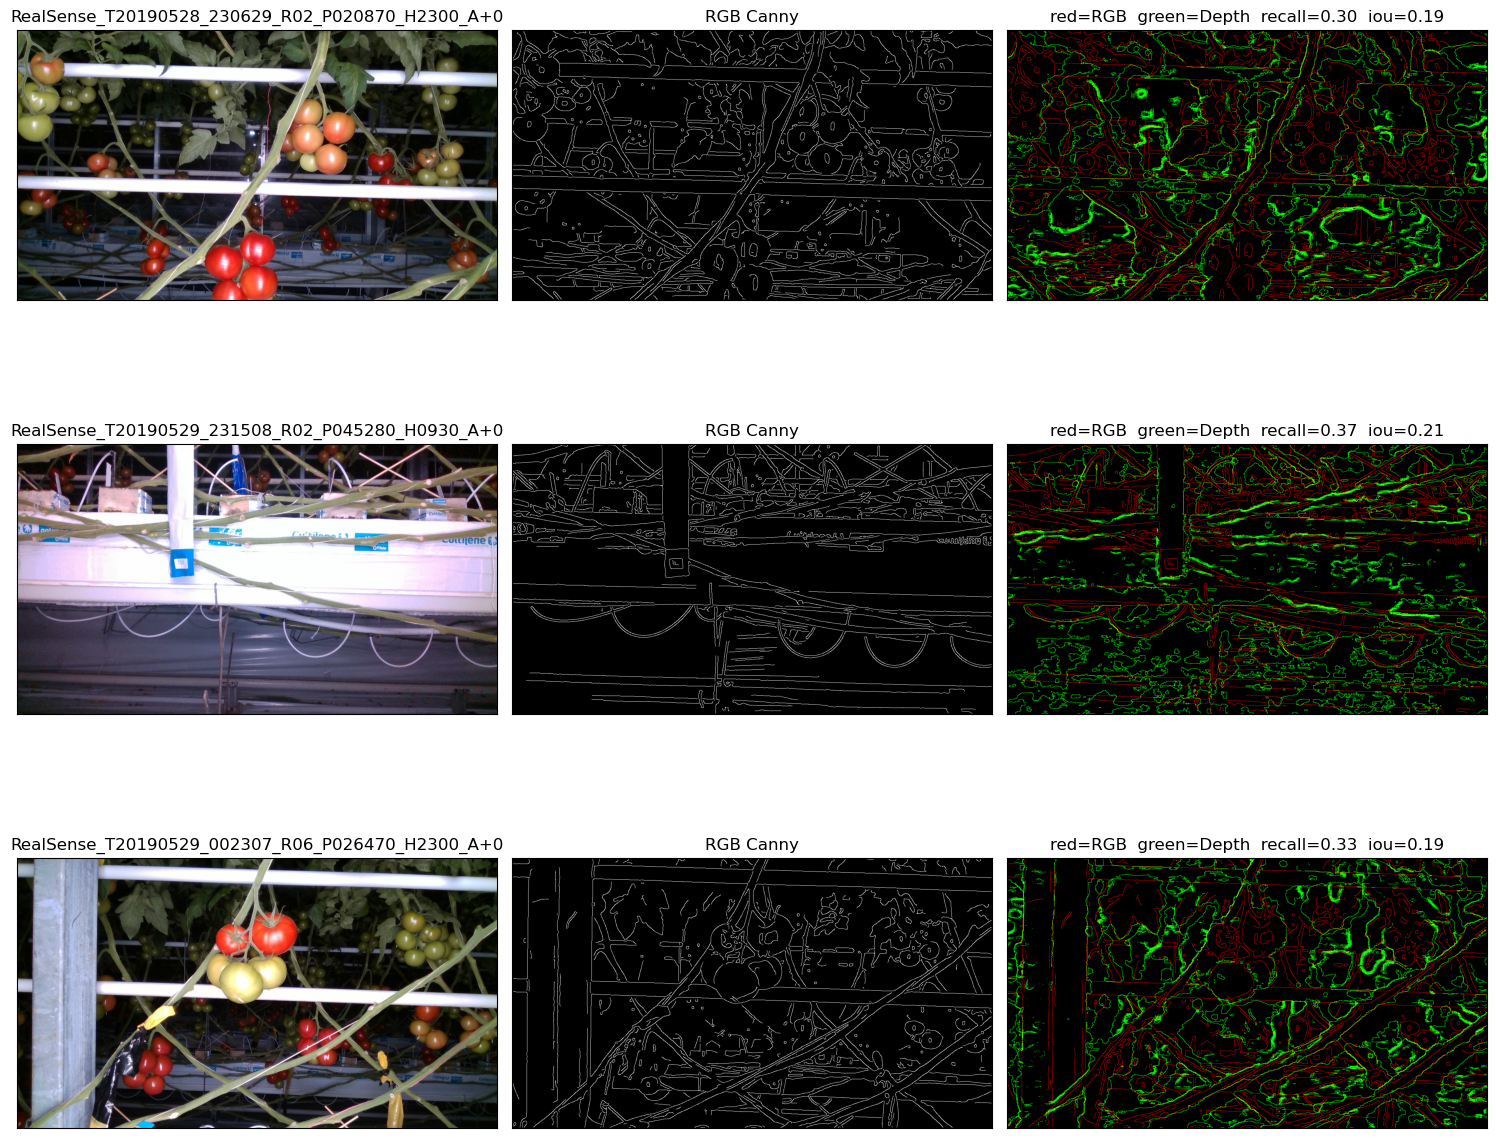

In [4]:
def edge_agreement(rgb, depth, tol_px=3):
    gray = rgb.mean(axis=2) / 255.0
    rgb_edges = canny(gray, sigma=2.0)

    valid = depth > 0
    if valid.sum() < 100:
        return None
    d = depth.astype(np.float32)
    d_filled = np.where(valid, d, float(d[valid].mean()))
    grad = sobel(d_filled)
    thresh = np.percentile(grad[valid], 90)
    depth_edges = (grad > thresh) & valid

    depth_band = ndi.binary_dilation(depth_edges, iterations=tol_px)
    rgb_band = ndi.binary_dilation(rgb_edges, iterations=tol_px)

    n_rgb = rgb_edges.sum()
    recall = (rgb_edges & depth_band).sum() / max(n_rgb, 1)
    inter = (rgb_band & depth_band).sum()
    union = (rgb_band | depth_band).sum()
    iou = inter / max(union, 1)
    return {
        "edge_recall": float(recall),
        "edge_iou": float(iou),
        "rgb_edges": rgb_edges,
        "depth_edges": depth_edges,
    }

demo_ids = sample_ids[:3]
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 4.5 * len(demo_ids)))
for r, sid in enumerate(demo_ids):
    rgb, depth = load_pair(imgs[sid])
    res = edge_agreement(rgb, depth)
    axes[r,0].imshow(rgb); axes[r,0].set_title(stem_for(imgs[sid])[:48])
    axes[r,1].imshow(res["rgb_edges"], cmap="gray"); axes[r,1].set_title("RGB Canny")
    overlay = np.zeros((*res["rgb_edges"].shape, 3))
    overlay[..., 0] = res["rgb_edges"]
    overlay[..., 1] = res["depth_edges"]
    axes[r,2].imshow(overlay)
    axes[r,2].set_title(f"red=RGB  green=Depth  recall={res['edge_recall']:.2f}  iou={res['edge_iou']:.2f}")
    for ax in axes[r]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Dataset-wide stats (computed inline)

Rob2Pheno is small enough (83 train images) that we can run the full per-image analysis in the notebook rather than relying on a precomputed report. For each image we compute `valid_frac_in_fruit`, depth p5/p95 range, and `edge_recall`/`edge_iou`.

In [5]:
records = []
for k, (img_id, im) in enumerate(imgs.items()):
    rgb, depth = load_pair(im)
    h, w = depth.shape
    fruit, _ = rasterize_fruit_mask(anns_by_img.get(img_id, []), h, w)
    valid = depth > 0
    fruit_area = int(fruit.sum())
    valid_in_fruit = int((valid & fruit).sum())
    valid_frac_in_fruit = valid_in_fruit / fruit_area if fruit_area else float("nan")
    valid_d = depth[valid]
    if valid_d.size:
        p5 = float(np.percentile(valid_d, 5))
        p95 = float(np.percentile(valid_d, 95))
    else:
        p5 = p95 = 0.0
    ea = edge_agreement(rgb, depth)
    records.append({
        "img_id": img_id,
        "stem": stem_for(im),
        "valid_frac_overall": float(valid.mean()),
        "valid_frac_in_fruit": float(valid_frac_in_fruit),
        "depth_p5": p5,
        "depth_p95": p95,
        "depth_range": p95 - p5,
        "edge_recall": ea["edge_recall"] if ea else float("nan"),
        "edge_iou": ea["edge_iou"] if ea else float("nan"),
    })
    if (k + 1) % 20 == 0:
        print(f"  {k+1}/{len(imgs)}")

print(f"done — {len(records)} records")

  20/83
  40/83
  60/83
  80/83
done — 83 records


valid_frac_in_fruit  mean=0.944  median=0.959  min=0.498  <0.30: 0/71
depth_range          mean=228.6  median=229.0
edge_recall          mean=0.341  median=0.338
edge_iou             mean=0.203  median=0.206


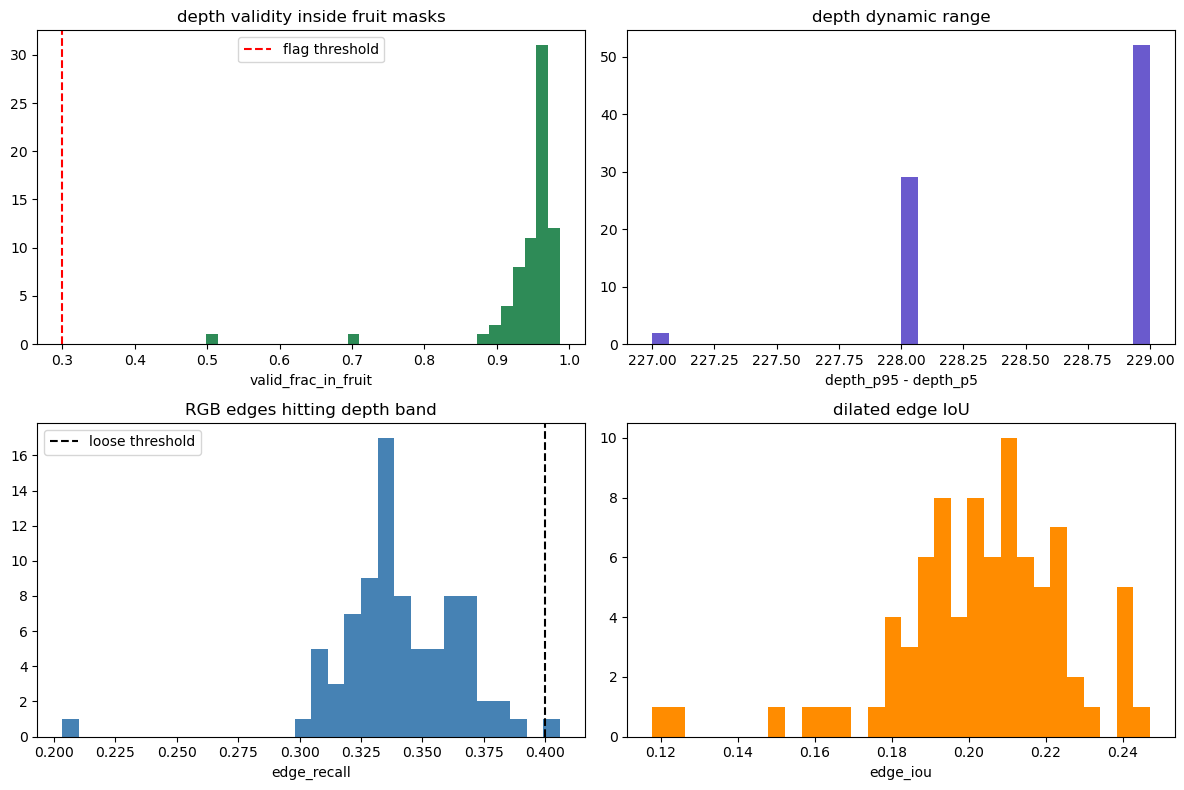

In [6]:
vf = np.array([r["valid_frac_in_fruit"] for r in records if r["valid_frac_in_fruit"] == r["valid_frac_in_fruit"]])
dr = np.array([r["depth_range"] for r in records])
rec = np.array([r["edge_recall"] for r in records if r["edge_recall"] == r["edge_recall"]])
iou = np.array([r["edge_iou"] for r in records if r["edge_iou"] == r["edge_iou"]])

print(f"valid_frac_in_fruit  mean={vf.mean():.3f}  median={np.median(vf):.3f}  min={vf.min():.3f}  <0.30: {(vf<0.3).sum()}/{len(vf)}")
print(f"depth_range          mean={dr.mean():.1f}  median={np.median(dr):.1f}")
print(f"edge_recall          mean={rec.mean():.3f}  median={np.median(rec):.3f}")
print(f"edge_iou             mean={iou.mean():.3f}  median={np.median(iou):.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(vf, bins=30, color="seagreen")
axes[0,0].axvline(0.3, color="red", ls="--", label="flag threshold")
axes[0,0].set_xlabel("valid_frac_in_fruit"); axes[0,0].set_title("depth validity inside fruit masks"); axes[0,0].legend()
axes[0,1].hist(dr, bins=30, color="slateblue")
axes[0,1].set_xlabel("depth_p95 - depth_p5"); axes[0,1].set_title("depth dynamic range")
axes[1,0].hist(rec, bins=30, color="steelblue")
axes[1,0].axvline(0.4, color="k", ls="--", label="loose threshold")
axes[1,0].set_xlabel("edge_recall"); axes[1,0].set_title("RGB edges hitting depth band"); axes[1,0].legend()
axes[1,1].hist(iou, bins=30, color="darkorange")
axes[1,1].set_xlabel("edge_iou"); axes[1,1].set_title("dilated edge IoU")
plt.tight_layout(); plt.show()

### Worst-by-valid-in-fruit
The 6 images with the lowest `valid_frac_in_fruit` — these are the most likely to be misaligned or to have sparse depth coverage on the fruits.

  RealSense_T20190613_231937_R03_P002510_H2300_A+000  valid_frac_in_fruit=0.895  edge_recall=0.37
  RealSense_T20190613_231946_R03_P002880_H1630_A+000  valid_frac_in_fruit=0.910  edge_recall=0.41
  RealSense_T20190528_230017_R02_P003280_H1630_A+000  valid_frac_in_fruit=0.916  edge_recall=0.34
  RealSense_T20190613_231937_R03_P002510_H1630_A+000  valid_frac_in_fruit=0.925  edge_recall=0.39
  RealSense_T20190528_232550_R03_P022870_H0930_A+000  valid_frac_in_fruit=0.930  edge_recall=0.34
  RealSense_T20190528_233421_R03_P046880_H2300_A+000  valid_frac_in_fruit=0.931  edge_recall=0.33


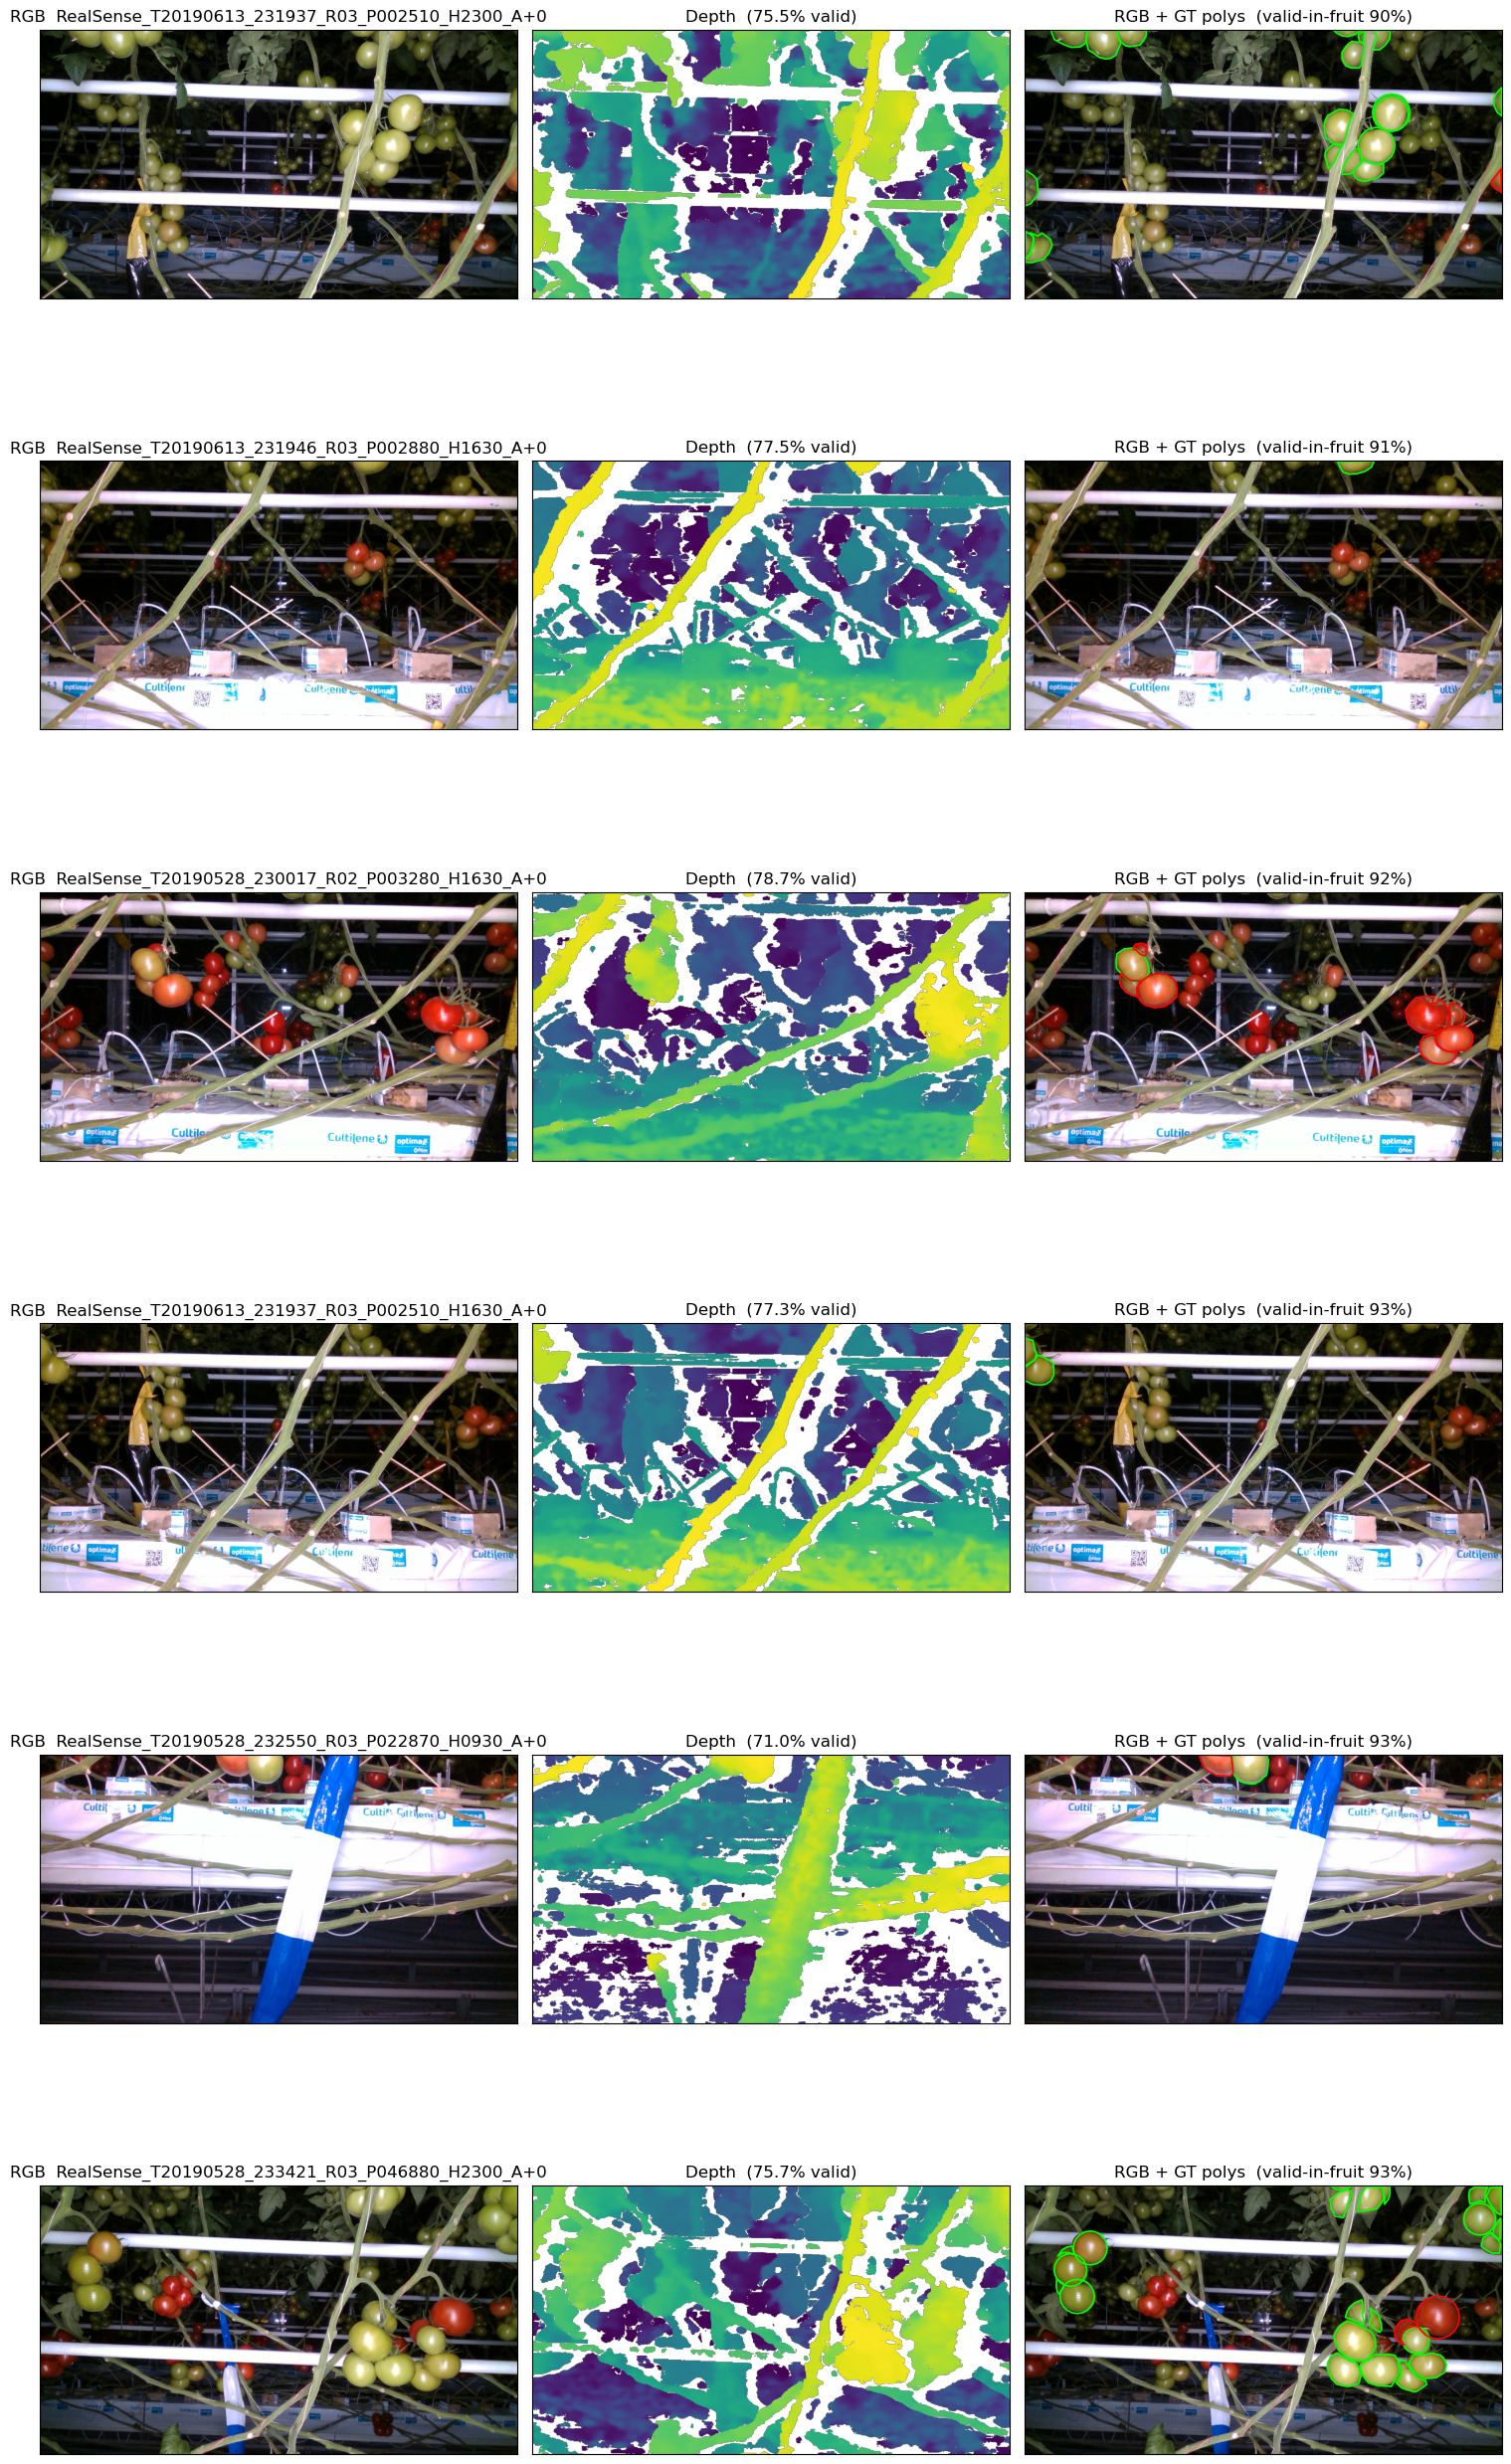

In [7]:
worst = sorted(records, key=lambda r: r["valid_frac_in_fruit"])[:6]
for w in worst:
    print(f"  {w['stem'][:60]}  valid_frac_in_fruit={w['valid_frac_in_fruit']:.3f}  edge_recall={w['edge_recall']:.2f}")

fig, axes = plt.subplots(len(worst), 3, figsize=(15, 4.5 * len(worst)))
for r, w in enumerate(worst):
    show_pair(imgs[w["img_id"]], axes[r])
plt.tight_layout(); plt.show()

## Interpretation cheatsheet

| Signal | Aligned | Misaligned |
|---|---|---|
| Visual overlay | Depth-map fruit blobs sit under red/green polygons | Depth blobs offset / scaled differently |
| Red+green edge overlay | Mostly yellow (overlap) on fruit silhouettes | Parallel red & green lines (shift) |
| `edge_recall` distribution | Median ≳ 0.4 | Median < 0.2, long left tail |
| `valid_frac_in_fruit` | Strongly right-skewed, mode > 0.9 | Bimodal or shifted toward 0 |
